
# Pelvis KNN Regression — Five Experiments

Predict left and right 3D ground reaction forces from pelvis IMU data.

| Experiment | Model inputs |
|---|---|
| 1 | Raw IMU |
| 2 | Raw IMU with a different K search |
| 3 | Raw IMU + mean, standard deviation, minimum, and maximum |
| 4 | Raw IMU + acceleration and gyroscope magnitudes |
| 5 | Raw IMU + statistics + magnitudes |

- Participant split: 40 training, 9 validation, 9 testing.
- Input scaling: StandardScaler fitted on training inputs only.
- KNN: Euclidean distance and uniform neighbour weighting.
- K selection: Lowest validation RMSE.
- Sensitivity analysis: Validation RMSE table and plot across K.
- Test metrics: RMSE, Pearson correlation, and R².
- Outputs: Left and right Fx, Fy, and Fz.

## **1. Notebook set-up**

In [1]:
from pathlib import Path
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.neighbors import (
    KNeighborsRegressor
)

from sklearn.preprocessing import (
    StandardScaler
)

In [2]:
DATA_ROOT = Path("/kaggle/input")

files = list(
    DATA_ROOT.rglob("combined_pelvis_bilateral_grf.csv")
)

print("Matching files:", len(files))

for file in files:
    print(file)

assert len(files) == 1, "Expected one matching pelvis file."

Matching files: 1
/kaggle/input/datasets/toffickmohammed/gait-mphil-research-data/combined_pelvis_bilateral_grf.csv


In [3]:
pelvis = pd.read_csv(
    files[0],
    dtype={"Participant": str}
)

print("Dataset shape:", pelvis.shape)
display(pelvis.head())

Dataset shape: (1015, 1204)


,Dataset,Participant,Trial,Side,Pelvis_Acc_X_t0,Pelvis_Acc_X_t1,Pelvis_Acc_X_t2,Pelvis_Acc_X_t3,Pelvis_Acc_X_t4,Pelvis_Acc_X_t5,...,GRF_Right_Fz_t90,GRF_Right_Fz_t91,GRF_Right_Fz_t92,GRF_Right_Fz_t93,GRF_Right_Fz_t94,GRF_Right_Fz_t95,GRF_Right_Fz_t96,GRF_Right_Fz_t97,GRF_Right_Fz_t98,GRF_Right_Fz_t99
0,Lavikainen,01,l_comf_01,Bilateral,13.867336,12.599382,11.367044,12.683041,15.075952,15.030770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Lavikainen,01,l_comf_02,Bilateral,13.539703,12.185856,11.601151,13.073038,13.831650,12.348832,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Lavikainen,01,l_comf_03,Bilateral,13.356306,13.091857,11.960903,11.781584,13.496060,14.636293,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Lavikainen,01,l_comf_04,Bilateral,13.174028,12.261867,11.914104,13.159199,13.695015,12.421048,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Lavikainen,01,l_comf_05,Bilateral,13.039537,12.526015,11.685674,12.857979,14.537988,13.939563,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
TIME_POINTS = 100

IMU_CHANNELS = [
    "Acc_X", "Acc_Y", "Acc_Z",
    "Gyr_X", "Gyr_Y", "Gyr_Z"
]

GRF_CHANNELS = [
    "Left_Fx", "Left_Fy", "Left_Fz",
    "Right_Fx", "Right_Fy", "Right_Fz"
]

METADATA = [
    "Dataset", "Participant", "Trial", "Side"
]

In [5]:
x_columns = [
    f"Pelvis_{channel}_t{t}"
    for channel in IMU_CHANNELS
    for t in range(TIME_POINTS)
]

y_columns = [
    f"GRF_{channel}_t{t}"
    for channel in GRF_CHANNELS
    for t in range(TIME_POINTS)
]

required = METADATA + x_columns + y_columns
missing = set(required) - set(pelvis.columns)

print("Missing columns:", sorted(missing))
assert not missing, "Required columns are missing."

print("Input features:", len(x_columns))
print("Target features:", len(y_columns))

Missing columns: []
Input features: 600
Target features: 600


In [6]:
assert not pelvis[METADATA].isna().any().any(), "Missing metadata."

signals = pelvis[x_columns + y_columns].to_numpy(dtype=float)

assert np.isfinite(signals).all(), "Missing or infinite signal values."

print("Missing-value checks passed.")

Missing-value checks passed.


In [7]:
pelvis["Group_ID"] = (
    pelvis["Dataset"].astype(str).str.strip()
    + "::"
    + pelvis["Participant"].str.strip()
)

participants = pelvis["Group_ID"].nunique()

print("Participants:", participants)
assert participants == 58, "Expected 58 participants."

display(
    pelvis.groupby("Dataset")["Group_ID"].nunique()
)

Participants: 58


Dataset
Grouvel       10
Lavikainen    48
Name: Group_ID, dtype: int64

In [8]:
pelvis["Side"] = (
    pelvis["Side"].str.strip().str.title()
)

display(pelvis["Side"].value_counts())

assert pelvis["Side"].isin(
    ["Left", "Right", "Bilateral"]
).all(), "Unexpected Side labels."

Side
Bilateral    935
Left          45
Right         35
Name: count, dtype: int64

## 2. Create participant splits

In [9]:
participant_table = (
    pelvis[["Group_ID", "Dataset", "Participant"]]
    .drop_duplicates("Group_ID")
    .reset_index(drop=True)
)

print("Participants:", len(participant_table))
print(participant_table["Dataset"].value_counts())

Participants: 58
Dataset
Lavikainen    48
Grouvel       10
Name: count, dtype: int64


In [10]:
SEED = 42

train_table, remaining_table = train_test_split(
    participant_table,
    train_size=40,
    test_size=18,
    stratify=participant_table["Dataset"],
    random_state=SEED
)

val_table, test_table = train_test_split(
    remaining_table,
    train_size=9,
    test_size=9,
    stratify=remaining_table["Dataset"],
    random_state=SEED
)

train_ids = train_table["Group_ID"].to_numpy()
val_ids = val_table["Group_ID"].to_numpy()
test_ids = test_table["Group_ID"].to_numpy()

In [11]:
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(val_ids).isdisjoint(test_ids)

print("Training:", len(train_ids))
print("Validation:", len(val_ids))
print("Testing:", len(test_ids))
print("Participant overlap: None")

Training: 40
Validation: 9
Testing: 9
Participant overlap: None


In [12]:
split_table = pd.concat([
    train_table.assign(Split="Train"),
    val_table.assign(Split="Validation"),
    test_table.assign(Split="Test")
], ignore_index=True)

display(
    split_table.groupby(["Split", "Dataset"])
    ["Group_ID"].nunique()
)

Split       Dataset   
Test        Grouvel        2
            Lavikainen     7
Train       Grouvel        7
            Lavikainen    33
Validation  Grouvel        1
            Lavikainen     8
Name: Group_ID, dtype: int64

### **Experiment one**

In [13]:
# ## experiment settings
# EXPERIMENT = "experiment_3_raw_pelvis_"
#     "statistical_summary"

# SENSORS = ["Pelvis"]

# # K_VALUES = list(range(1, 101, 5)) + [100]
# K_VALUES = list(range(1, 21)) + list(range(25, 101, 5)) + list(range(125, 501, 25)) 

# WEIGHTS = "uniform"
# METRIC = "euclidean"

# OUTPUT_PATH = (
#     Path("/kaggle/working") / EXPERIMENT
# )
# OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# print("Experiment:", EXPERIMENT)
# print("K values:", K_VALUES)
# print("Save location:", OUTPUT_PATH)

In [14]:
EXPERIMENT = (
    "experiment_5_raw_pelvis_"
    "statistics_magnitude"
)

SENSORS = ["Pelvis"]

K_VALUES = list(range(1, 21)) + list(range(25, 101, 5)) + list(range(125, 501, 25))

WEIGHTS = "uniform"
METRIC = "euclidean"

OUTPUT_PATH = (
    Path("/kaggle/working")
    / EXPERIMENT
)

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Experiment:", EXPERIMENT)
print("K values:", K_VALUES)
print("Save location:", OUTPUT_PATH)

Experiment: experiment_5_raw_pelvis_statistics_magnitude
K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450, 475, 500]
Save location: /kaggle/working/experiment_5_raw_pelvis_statistics_magnitude


In [15]:
## prepare the data
def prepare_raw_data(df):
    X = df[x_columns].to_numpy(dtype=np.float32)
    y = df[y_columns].to_numpy(dtype=np.float32)

    split_ids = {
        "train": train_ids,
        "val": val_ids,
        "test": test_ids
    }

    data = {}

    for split, ids in split_ids.items():
        mask = df["Group_ID"].isin(ids).to_numpy()

        data[f"X_{split}"] = X[mask]
        data[f"y_{split}"] = y[mask]
        data[f"side_{split}"] = df.loc[mask, "Side"].to_numpy()

    scaler = StandardScaler()

    data["X_train"] = scaler.fit_transform(data["X_train"])

    for split in ["val", "test"]:
        data[f"X_{split}"] = scaler.transform(data[f"X_{split}"])

    data["scaler"] = scaler

    return data

In [16]:
data = prepare_raw_data(pelvis)

for split in ["train", "val", "test"]:
    print(
        split,
        "X:", data[f"X_{split}"].shape,
        "y:", data[f"y_{split}"].shape
    )

train X: (696, 600) y: (696, 600)
val X: (165, 600) y: (165, 600)
test X: (154, 600) y: (154, 600)


In [17]:
def add_statistics(df):
    df = df.copy()

    for channel in IMU_CHANNELS:
        columns = [
            f"Pelvis_{channel}_t{time}"
            for time in range(TIME_POINTS)
        ]

        df[f"Pelvis_{channel}_mean"] = (
            df[columns].mean(axis=1)
        )

        df[f"Pelvis_{channel}_std"] = (
            df[columns].std(axis=1)
        )

        df[f"Pelvis_{channel}_min"] = (
            df[columns].min(axis=1)
        )

        df[f"Pelvis_{channel}_max"] = (
            df[columns].max(axis=1)
        )

    return df

In [18]:
stat_columns = [
    f"Pelvis_{channel}_{stat}"
    for channel in IMU_CHANNELS
    for stat in [
        "mean",
        "std",
        "min",
        "max"
    ]
]

pelvis_exp5 = add_statistics(
    pelvis
)

print(
    "Statistical columns:",
    len(stat_columns)
)

display(
    pelvis_exp5[stat_columns].head()
)

Statistical columns: 24


,Pelvis_Acc_X_mean,Pelvis_Acc_X_std,Pelvis_Acc_X_min,Pelvis_Acc_X_max,Pelvis_Acc_Y_mean,Pelvis_Acc_Y_std,Pelvis_Acc_Y_min,Pelvis_Acc_Y_max,Pelvis_Acc_Z_mean,Pelvis_Acc_Z_std,...,Pelvis_Gyr_X_min,Pelvis_Gyr_X_max,Pelvis_Gyr_Y_mean,Pelvis_Gyr_Y_std,Pelvis_Gyr_Y_min,Pelvis_Gyr_Y_max,Pelvis_Gyr_Z_mean,Pelvis_Gyr_Z_std,Pelvis_Gyr_Z_min,Pelvis_Gyr_Z_max
0,9.812009,3.173394,4.611431,15.527279,-1.109747,1.363329,-4.556126,1.843709,2.230555,1.849581,...,-1.176673,1.174845,-0.044843,0.319597,-0.862200,0.422291,0.051358,0.526541,-0.863114,1.231221
1,9.763484,2.914440,4.874941,15.424162,-1.133843,1.187268,-5.317983,2.226109,2.253893,1.928660,...,-0.978382,1.124931,-0.032562,0.305506,-0.807614,0.410221,0.045117,0.499976,-0.880569,1.086123
2,9.831766,3.126213,4.190568,14.883741,-1.118348,1.136829,-4.689591,1.914488,2.155224,1.769773,...,-1.066164,1.044346,-0.028833,0.291079,-0.744100,0.398991,0.034397,0.496688,-0.832637,1.095925
3,9.764174,2.776174,4.731235,14.801430,-1.140926,0.961054,-4.058451,1.529030,2.239477,1.661299,...,-0.818668,1.010317,-0.026604,0.300622,-0.741064,0.431145,0.047727,0.481082,-0.659515,1.150135
4,9.758720,2.558836,4.946380,14.537988,-1.145637,0.909643,-3.779031,1.262771,2.344890,1.796622,...,-0.935994,0.839743,-0.045945,0.298488,-0.820209,0.416907,0.050672,0.500761,-0.779231,1.221330


In [19]:
def add_magnitudes(df):
    def get_axes(signal):
        return np.stack([
            df[[
                f"Pelvis_{signal}_{axis}_t{time}"
                for time in range(TIME_POINTS)
            ]].to_numpy(dtype=np.float32)
            for axis in ["X", "Y", "Z"]
        ], axis=2)

    acc_magnitude = np.linalg.norm(
        get_axes("Acc"),
        axis=2
    )

    gyr_magnitude = np.linalg.norm(
        get_axes("Gyr"),
        axis=2
    )

    magnitude_columns = [
        f"Pelvis_{signal}_Magnitude_t{time}"
        for signal in ["Acc", "Gyr"]
        for time in range(TIME_POINTS)
    ]

    magnitude_data = pd.DataFrame(
        np.hstack([
            acc_magnitude,
            gyr_magnitude
        ]),
        columns=magnitude_columns,
        index=df.index
    )

    result = pd.concat(
        [df, magnitude_data],
        axis=1
    )

    return result, magnitude_columns

In [20]:
pelvis_exp5, magnitude_columns = (
    add_magnitudes(pelvis_exp5)
)

print(
    "Statistical columns:",
    len(stat_columns)
)

print(
    "Magnitude columns:",
    len(magnitude_columns)
)

display(
    pelvis_exp5[magnitude_columns].head()
)

Statistical columns: 24
Magnitude columns: 200


,Pelvis_Acc_Magnitude_t0,Pelvis_Acc_Magnitude_t1,Pelvis_Acc_Magnitude_t2,Pelvis_Acc_Magnitude_t3,Pelvis_Acc_Magnitude_t4,Pelvis_Acc_Magnitude_t5,Pelvis_Acc_Magnitude_t6,Pelvis_Acc_Magnitude_t7,Pelvis_Acc_Magnitude_t8,Pelvis_Acc_Magnitude_t9,...,Pelvis_Gyr_Magnitude_t90,Pelvis_Gyr_Magnitude_t91,Pelvis_Gyr_Magnitude_t92,Pelvis_Gyr_Magnitude_t93,Pelvis_Gyr_Magnitude_t94,Pelvis_Gyr_Magnitude_t95,Pelvis_Gyr_Magnitude_t96,Pelvis_Gyr_Magnitude_t97,Pelvis_Gyr_Magnitude_t98,Pelvis_Gyr_Magnitude_t99
0,14.367242,13.229330,11.742491,13.835889,16.502310,16.182993,13.939198,12.314419,10.802709,10.153439,...,0.784923,0.421846,0.206179,0.228557,0.505084,0.911992,1.280341,1.477455,1.419635,1.191004
1,13.920284,12.392381,12.097334,14.246545,15.144725,13.419829,12.703097,11.858317,11.263290,12.007596,...,0.814547,0.555106,0.394080,0.326775,0.398472,0.631891,0.911827,1.122212,1.181420,1.111942
2,13.506597,13.452309,12.171091,12.264198,14.461206,15.686346,14.504302,12.754792,10.938993,9.458340,...,0.938158,0.692962,0.329343,0.163616,0.363987,0.740919,1.150617,1.412751,1.372970,1.173293
3,13.585667,12.555234,12.430710,14.124055,14.635033,13.179102,12.406358,11.402907,10.311144,10.655303,...,0.780322,0.488694,0.282725,0.270750,0.501180,0.855859,1.166050,1.333742,1.278220,1.075097
4,13.305114,12.840267,12.001598,13.796902,15.557543,14.874335,13.531828,12.458235,11.508251,11.609215,...,0.552444,0.370138,0.308266,0.376064,0.633280,0.995044,1.295588,1.438461,1.363327,1.105581


In [21]:
def prepare_experiment_five(df):
    input_columns = (
        x_columns
        + stat_columns
        + magnitude_columns
    )

    X = df[input_columns].to_numpy(
        dtype=np.float32
    )

    y = df[y_columns].to_numpy(
        dtype=np.float32
    )

    split_ids = {
        "train": train_ids,
        "val": val_ids,
        "test": test_ids
    }

    data = {}

    for split, ids in split_ids.items():
        mask = (
            df["Group_ID"]
            .isin(ids)
            .to_numpy()
        )

        data[f"X_{split}"] = X[mask]
        data[f"y_{split}"] = y[mask]

        data[f"side_{split}"] = (
            df.loc[mask, "Side"]
            .to_numpy()
        )

    scaler = StandardScaler()

    data["X_train"] = scaler.fit_transform(
        data["X_train"]
    )

    for split in ["val", "test"]:
        data[f"X_{split}"] = scaler.transform(
            data[f"X_{split}"]
        )

    data["scaler"] = scaler
    data["input_columns"] = input_columns

    return data

In [22]:
data = prepare_experiment_five(
    pelvis_exp5
)

for split in ["train", "val", "test"]:
    print(
        split,
        "X:",
        data[f"X_{split}"].shape,
        "y:",
        data[f"y_{split}"].shape
    )

print("Raw features:", len(x_columns))
print("Statistical features:", len(stat_columns))
print("Magnitude features:", len(magnitude_columns))
print(
    "Total input features:",
    len(data["input_columns"])
)

assert len(x_columns) == 600
assert len(stat_columns) == 24
assert len(magnitude_columns) == 200
assert len(data["input_columns"]) == 824
assert data["X_train"].shape[1] == 824
assert data["y_train"].shape[1] == 600

print("Experiment 5 data prepared correctly.")

train X: (696, 824) y: (696, 600)
val X: (165, 824) y: (165, 600)
test X: (154, 824) y: (154, 600)
Raw features: 600
Statistical features: 24
Magnitude features: 200
Total input features: 824
Experiment 5 data prepared correctly.


In [23]:
# for split in ["train", "val", "test"]:
#     print(
#         split,
#         "X:", data[f"X_{split}"].shape,
#         "y:", data[f"y_{split}"].shape
#     )

# print(
#     "Input columns:",
#     len(data["input_columns"])
# )

### K selection and sensitivity analysis

- Predict validation GRF for each K.
- Exclude unmeasured target sides from scoring.
- Select K with the lowest validation RMSE.
- Calculate the percentage increase above the minimum RMSE.
- Save the table and plot.

In [24]:
def validation_rmse(actual, predicted, sides):
    measured = np.column_stack([
        np.isin(sides, ["Left", "Bilateral"]),
        np.isin(sides, ["Right", "Bilateral"])
    ])

    mask = np.repeat(
        measured,
        3 * TIME_POINTS,
        axis=1
    )

    errors = predicted - actual

    return np.sqrt(np.mean(errors[mask] ** 2))

In [25]:
def validate_knn_experiment_five(data):
    results = []

    for k in K_VALUES:
        if k > len(data["X_train"]):
            continue

        model = KNeighborsRegressor(
            n_neighbors=k,
            weights=WEIGHTS,
            metric=METRIC,
            n_jobs=-1
        )

        model.fit(
            data["X_train"],
            data["y_train"]
        )

        prediction = model.predict(
            data["X_val"]
        )

        rmse = validation_rmse(
            data["y_val"],
            prediction,
            data["side_val"]
        )

        results.append({
            "K": k,
            "Validation_RMSE_N": rmse
        })

    return (
        pd.DataFrame(results)
        .sort_values("K")
        .reset_index(drop=True)
    )

In [26]:
score_table = (
    validate_knn_experiment_five(data)
)

best_row = score_table.loc[
    score_table[
        "Validation_RMSE_N"
    ].idxmin()
]

best_k = int(
    best_row["K"]
)

best_rmse = float(
    best_row["Validation_RMSE_N"]
)

score_table["Increase_Percent"] = (
    100
    * (
        score_table["Validation_RMSE_N"]
        - best_rmse
    )
    / best_rmse
)

near_best = score_table[
    score_table["Validation_RMSE_N"]
    <= best_rmse * 1.01
]

display(
    score_table.round(3)
)

print("Best K:", best_k)

print(
    "Validation RMSE:",
    round(best_rmse, 3),
    "N"
)

print(
    "K values within 1%:",
    near_best["K"].tolist()
)

if best_k == score_table["K"].max():
    print(
        "Best K is at the upper search boundary."
    )

,K,Validation_RMSE_N,Increase_Percent
0,1,85.725998,23.554001
1,2,87.088997,25.518999
2,3,95.342003,37.412998
3,4,98.511002,41.980000
4,5,100.653999,45.069000
5,6,103.545998,49.237999
6,7,104.660004,50.842999
7,8,105.828003,52.526001
8,9,106.754997,53.862999
9,10,107.739998,55.282001


Best K: 250
Validation RMSE: 69.383 N
K values within 1%: [225, 250, 275, 300, 325, 350]


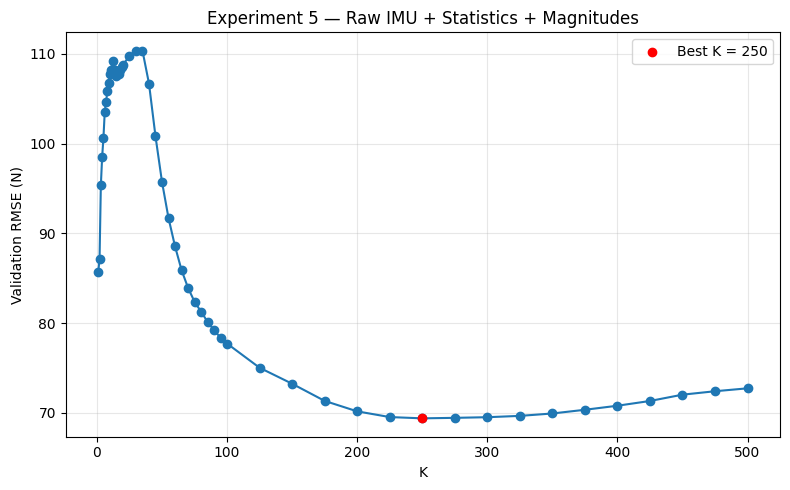

Experiment 5 table and graph saved.


In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    score_table["K"],
    score_table["Validation_RMSE_N"],
    marker="o"
)

plt.scatter(
    best_k,
    best_rmse,
    color="red",
    label=f"Best K = {best_k}",
    zorder=3
)

plt.xlabel("K")
plt.ylabel("Validation RMSE (N)")

plt.title(
    "Experiment 5 — Raw IMU + Statistics + Magnitudes"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_PATH
    / "experiment_5_k_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

score_table.to_csv(
    OUTPUT_PATH
    / "experiment_5_k_sensitivity.csv",
    index=False
)

print("Experiment 5 table and graph saved.")

### Train the final model

- Use the K selected through validation.
- Fit with training inputs and targets.
- Predict left and right GRF together.

In [28]:
final_model = KNeighborsRegressor(
    n_neighbors=best_k,
    weights=WEIGHTS,
    metric=METRIC,
    n_jobs=-1
)

final_model.fit(
    data["X_train"],
    data["y_train"]
)

print("Selected K:", best_k)
print("Input features:", data["X_train"].shape[1])
print("Output targets:", data["y_train"].shape[1])

Selected K: 250
Input features: 824
Output targets: 600


In [29]:
joblib.dump(
    final_model,
    OUTPUT_PATH
    / "knn_model_experiment_5.joblib"
)

joblib.dump(
    data["scaler"],
    OUTPUT_PATH
    / "input_scaler_experiment_5.joblib"
)

joblib.dump(
    data["input_columns"],
    OUTPUT_PATH
    / "input_columns_experiment_5.joblib"
)

print(
    "Experiment 5 model, scaler, "
    "and input-column order saved."
)

Experiment 5 model, scaler, and input-column order saved.


### Test evaluation

- Predict left and right GRF for test participants.
- Calculate RMSE, Pearson correlation, and R² per side and axis.
- Exclude unmeasured target sides using the Side labels.
- Keep measured zero values in the evaluation.
- Report force errors in Newtons.

In [30]:
test_prediction = final_model.predict(
    data["X_test"]
)

print(
    "Test input shape:",
    data["X_test"].shape
)

print(
    "Prediction shape:",
    test_prediction.shape
)

Test input shape: (154, 824)
Prediction shape: (154, 600)


In [31]:
def evaluate_knn(actual, predicted, sides):
    results = []

    for index, channel in enumerate(
        GRF_CHANNELS
    ):
        side, axis = channel.split("_")

        mask = np.isin(
            sides,
            [side, "Bilateral"]
        )

        start = index * TIME_POINTS
        stop = start + TIME_POINTS

        measured = actual[
            mask,
            start:stop
        ].ravel()

        estimated = predicted[
            mask,
            start:stop
        ].ravel()

        if measured.size < 2:
            rmse = np.nan
            correlation = np.nan
            r_squared = np.nan

        else:
            rmse = np.sqrt(
                np.mean(
                    (estimated - measured) ** 2
                )
            )

            correlation = (
                pearsonr(
                    measured,
                    estimated
                )[0]
                if (
                    np.std(measured) > 0
                    and np.std(estimated) > 0
                )
                else np.nan
            )

            r_squared = (
                r2_score(
                    measured,
                    estimated
                )
                if np.std(measured) > 0
                else np.nan
            )

        results.append({
            "Side": side,
            "Axis": axis,
            "Samples": int(mask.sum()),
            "RMSE_N": rmse,
            "Pearson_r": correlation,
            "R2": r_squared
        })

    return pd.DataFrame(results)

In [32]:
test_results = evaluate_knn(
    data["y_test"],
    test_prediction,
    data["side_test"]
)

display(
    test_results.round(3)
)

test_results.to_csv(
    OUTPUT_PATH
    / "test_metrics_experiment_5.csv",
    index=False
)

print("Experiment 5 test metrics saved.")

,Side,Axis,Samples,RMSE_N,Pearson_r,R2
0,Left,Fx,145,16.815001,0.804,0.537
1,Left,Fy,145,32.409000,0.927,0.840
2,Left,Fz,145,144.261002,0.935,0.831
3,Right,Fx,146,12.944000,0.856,0.655
4,Right,Fy,146,27.145000,0.918,0.813
5,Right,Fz,146,134.673996,0.947,0.866


Experiment 5 test metrics saved.


In [33]:
report = f"""
PELVIS KNN — EXPERIMENT 5
==================================================

INPUTS AND TARGETS
Raw pelvis acceleration and gyroscope
Engineered features: Statistical summaries and magnitude waveforms
Statistics: Mean, standard deviation, minimum and maximum
Magnitudes: Acceleration and gyroscope magnitude at each time point
Raw input features: {len(x_columns)}
Statistical features: {len(stat_columns)}
Magnitude features: {len(magnitude_columns)}
Total input features: {data["X_train"].shape[1]}
Time points: {TIME_POINTS}
Target features: {data["y_train"].shape[1]}
Target order: {", ".join(GRF_CHANNELS)}
GRF units: Newtons

PARTICIPANT SPLIT
Training: {len(train_ids)}
Validation: {len(val_ids)}
Testing: {len(test_ids)}
Random seed: {SEED}
Participant overlap: {
    bool(
        set(train_ids) & set(val_ids)
        or set(train_ids) & set(test_ids)
        or set(val_ids) & set(test_ids)
    )
}

SAMPLE COUNTS
Training: {len(data["X_train"])}
Validation: {len(data["X_val"])}
Testing: {len(data["X_test"])}

SCALING
Statistical and magnitude features calculated before scaling
StandardScaler fitted on all training input features
Validation and test inputs transformed with the training scaler
Target scaling: None

MODEL
K-nearest neighbours regression
Distance: {METRIC}
Neighbour weighting: {WEIGHTS}
Final model fitted on training samples only
Left and right GRF predicted together

K SELECTION AND SENSITIVITY
K values tested: {score_table["K"].tolist()}
Selection: Lowest pooled validation RMSE
Selected K: {best_k}
Minimum validation RMSE: {best_rmse:.3f} N
K values within 1% of minimum: {near_best["K"].tolist()}
Selected K at upper boundary: {best_k == score_table["K"].max()}
The 1% tolerance describes validation sensitivity.

VALIDATION RESULTS
{score_table.round(3).to_string(index=False)}

EVALUATION
Metrics pooled across samples and time points for each side and axis
Unmeasured sides excluded using Side labels
Measured zero values retained
Test data excluded from K selection
Metrics: RMSE, Pearson correlation and R-squared

TEST RESULTS
{test_results.round(3).to_string(index=False)}

LIMITATION
Zero-filled unmeasured targets remain in training.
Their effect on predictions has not been quantified.
Exclusion during scoring depends on accurate Side labels.
"""

report_file = (
    OUTPUT_PATH
    / "experiment_5_summary.txt"
)

report_file.write_text(
    report,
    encoding="utf-8"
)

print(report)
print("Saved:", report_file)


PELVIS KNN — EXPERIMENT 5

INPUTS AND TARGETS
Raw pelvis acceleration and gyroscope
Engineered features: Statistical summaries and magnitude waveforms
Statistics: Mean, standard deviation, minimum and maximum
Magnitudes: Acceleration and gyroscope magnitude at each time point
Raw input features: 600
Statistical features: 24
Magnitude features: 200
Total input features: 824
Time points: 100
Target features: 600
Target order: Left_Fx, Left_Fy, Left_Fz, Right_Fx, Right_Fy, Right_Fz
GRF units: Newtons

PARTICIPANT SPLIT
Training: 40
Validation: 9
Testing: 9
Random seed: 42
Participant overlap: False

SAMPLE COUNTS
Training: 696
Validation: 165
Testing: 154

SCALING
Statistical and magnitude features calculated before scaling
StandardScaler fitted on all training input features
Validation and test inputs transformed with the training scaler
Target scaling: None

MODEL
K-nearest neighbours regression
Distance: euclidean
Neighbour weighting: uniform
Final model fitted on training samples onl